# NSL-KDD NID preprocessing and ML models
  
  This notebook contains the steps involved in preprocessing and break down the process into small milestones and we will apply some models and gonna evaluate the results
  
 ## The are steps involved in this process :
    
    1. Import libraries

    2. Load the dataset

    3. Clean the data

    4. Exploratory Data Analysis (EDA)

    5. Encode categorical features

    6. Scale features

    7. Split into train/test

    8. Train models

    9. Evaluate and compare

In [13]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment','urgent','hot',
    'num_failed_logins','logged_in','num_compromised','root_shell','su_attempted','num_root','num_file_creations',
    'num_shells','num_access_files','num_outbound_cmds','is_host_login','is_guest_login','count','srv_count',
    'serror_rate','srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate',
    'dst_host_count','dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate',
    'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','label','difficulty_level'
]

train_df = pd.read_csv("/content/drive/MyDrive/nsl-kdd/KDDTrain+.txt", header=None, names=columns)
test_df = pd.read_csv("/content/drive/MyDrive/nsl-kdd/KDDTest+.txt", header=None, names=columns)
print(train_df.head())
print(test_df.head())

   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   
3               0       0    0  ...                    1.00   
4               0       0    0  ...                    1.00   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                    0.03                         0.17   
1                    0.60                         0.88   
2             

In [35]:
attack_mapping = {
    'normal': 'normal',
    # DoS attacks
    'back':'DoS','land':'DoS','neptune':'DoS','pod':'DoS','smurf':'DoS',
    'teardrop':'DoS','apache2':'DoS','mailbomb':'DoS','processtable':'DoS','udpstorm':'DoS',
    # Probe attacks
    'satan':'Probe','ipsweep':'Probe','nmap':'Probe','portsweep':'Probe','mscan':'Probe','saint':'Probe',
    # R2L attacks
    'guess_passwd':'R2L','ftp_write':'R2L','imap':'R2L','phf':'R2L','multihop':'R2L','warezmaster':'R2L',
    'warezclient':'R2L','spy':'R2L','xlock':'R2L','xsnoop':'R2L','snmpguess':'R2L','snmpgetattack':'R2L',
    'httptunnel':'R2L','sendmail':'R2L','named':'R2L',
    # U2R attacks
    'buffer_overflow':'U2R','loadmodule':'U2R','rootkit':'U2R','perl':'U2R','xterm':'U2R','ps':'U2R','sqlattack':'U2R'
}

train_df['attack_class'] = train_df['label'].map(attack_mapping)
test_df['attack_class'] = test_df['label'].map(attack_mapping)


In [46]:
# For training set
print(train_df.isnull().sum())

# For test set
print(test_df.isnull().sum())


duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_h

In [47]:
print(train_df['attack_class'].isnull().sum())
print(test_df['attack_class'].isnull().sum())

# See which labels are causing NaN
print(train_df[train_df['attack_class'].isnull()]['label'].unique())
print(test_df[test_df['attack_class'].isnull()]['label'].unique())


0
0
[]
[]


In [43]:
print("NaNs in train:", train_df['attack_class'].isnull().sum())
print("NaNs in test:", test_df['attack_class'].isnull().sum())

train_df = train_df.dropna(subset=['attack_class'])
test_df = test_df.dropna(subset=['attack_class'])

NaNs in train: 0
NaNs in test: 0


In [49]:
print(train_df.isnull().sum())


duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_h

In [50]:
train_df = train_df.dropna()
test_df = test_df.dropna()


In [51]:
cat_cols = ['protocol_type','service','flag']
for col in cat_cols:
    train_df[col] = train_df[col].fillna(train_df[col].mode()[0])
    test_df[col] = test_df[col].fillna(train_df[col].mode()[0])


In [44]:
# Data types and info
print(train_df.info())
print(test_df.info())

# Check for missing values
print(train_df.isnull().sum())
print(test_df.isnull().sum())

# Check label distribution
print(train_df['label'].value_counts())
print(test_df['label'].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 45 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  int64  
 2   service                      125973 non-null  int64  
 3   flag                         125973 non-null  int64  
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13 

In [45]:
train_df['binary_label'] = train_df['label'].apply(lambda x: 0 if x=='normal' else 1)
test_df['binary_label'] = test_df['label'].apply(lambda x: 0 if x=='normal' else 1)


In [6]:
attack_mapping = {
    'normal': 'normal',
    # DoS attacks
    'back':'DoS','land':'DoS','neptune':'DoS','pod':'DoS','smurf':'DoS','teardrop':'DoS','apache2':'DoS','mailbomb':'DoS','processtable':'DoS','udpstorm':'DoS',
    # Probe attacks
    'satan':'Probe','ipsweep':'Probe','nmap':'Probe','portsweep':'Probe','mscan':'Probe','saint':'Probe',
    # R2L attacks
    'guess_passwd':'R2L','ftp_write':'R2L','imap':'R2L','phf':'R2L','multihop':'R2L','warezmaster':'R2L','warezclient':'R2L','spy':'R2L','xlock':'R2L','xsnoop':'R2L','snmpguess':'R2L','snmpgetattack':'R2L','httptunnel':'R2L','sendmail':'R2L','named':'R2L',
    # U2R attacks
    'buffer_overflow':'U2R','loadmodule':'U2R','rootkit':'U2R','perl':'U2R','sqlattack':'U2R','xterm':'U2R','ps':'U2R'
}

train_df['attack_class'] = train_df['label'].map(attack_mapping)
test_df['attack_class'] = test_df['label'].map(attack_mapping)


In [7]:
cat_cols = ['protocol_type', 'service', 'flag']


In [8]:
from sklearn.preprocessing import LabelEncoder

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col])
    test_df[col] = le.transform(test_df[col])
    le_dict[col] = le


In [9]:
X_train_bin = train_df.drop(['label', 'binary_label', 'attack_class', 'difficulty_level'], axis=1)
y_train_bin = train_df['binary_label']

X_test_bin = test_df.drop(['label', 'binary_label', 'attack_class', 'difficulty_level'], axis=1)
y_test_bin = test_df['binary_label']


In [53]:
X_train_multi = train_df.drop(['label', 'binary_label', 'attack_class', 'difficulty_level'], axis=1)
y_train_multi = train_df['attack_class']

X_test_multi = test_df.drop(['label', 'binary_label', 'attack_class', 'difficulty_level'], axis=1)
y_test_multi = test_df['attack_class']


In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_bin = scaler.fit_transform(X_train_bin)
X_test_bin = scaler.transform(X_test_bin)

X_train_multi = scaler.fit_transform(X_train_multi)
X_test_multi = scaler.transform(X_test_multi)


In [29]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}


=== Binary Classification ===

Logistic Regression
Accuracy: 0.7539034776437189
              precision    recall  f1-score   support

           0       0.65      0.93      0.77      9711
           1       0.93      0.62      0.74     12833

    accuracy                           0.75     22544
   macro avg       0.79      0.78      0.75     22544
weighted avg       0.81      0.75      0.75     22544



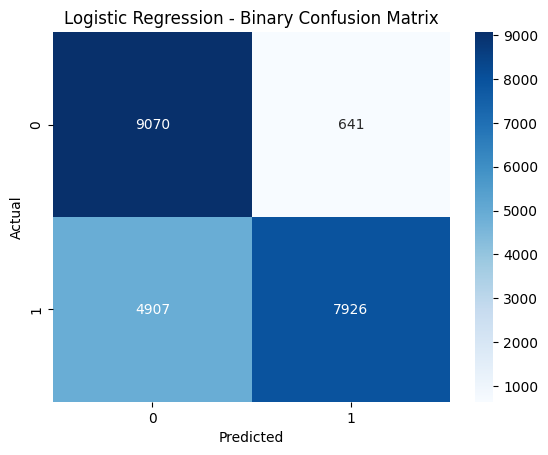


Decision Tree
Accuracy: 0.7885468417317246
              precision    recall  f1-score   support

           0       0.68      0.97      0.80      9711
           1       0.97      0.65      0.78     12833

    accuracy                           0.79     22544
   macro avg       0.82      0.81      0.79     22544
weighted avg       0.84      0.79      0.79     22544



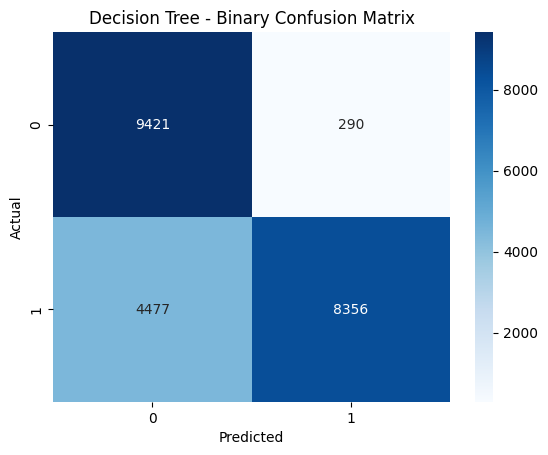


Random Forest
Accuracy: 0.7706706884315118
              precision    recall  f1-score   support

           0       0.66      0.97      0.78      9711
           1       0.97      0.62      0.75     12833

    accuracy                           0.77     22544
   macro avg       0.81      0.80      0.77     22544
weighted avg       0.83      0.77      0.77     22544



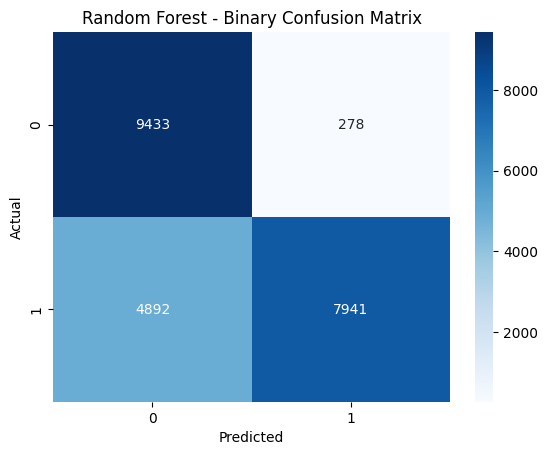


Gradient Boosting
Accuracy: 0.8064229950319376
              precision    recall  f1-score   support

           0       0.70      0.97      0.81      9711
           1       0.97      0.68      0.80     12833

    accuracy                           0.81     22544
   macro avg       0.83      0.83      0.81     22544
weighted avg       0.85      0.81      0.81     22544



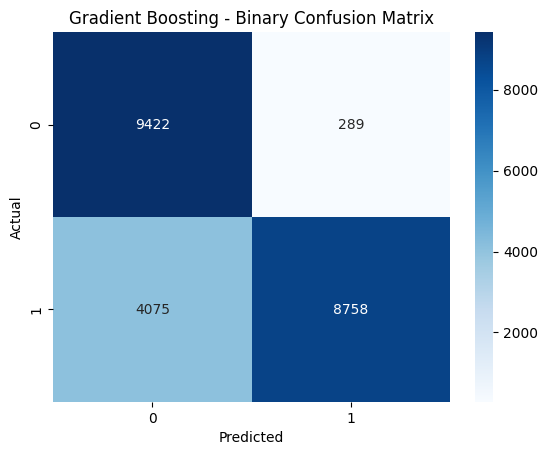

In [26]:
print("=== Binary Classification ===")
for name, model in models.items():
    model.fit(X_train_bin, y_train_bin)
    y_pred = model.predict(X_test_bin)

    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test_bin, y_pred))
    print(classification_report(y_test_bin, y_pred))

    # Confusion matrix
    cm = confusion_matrix(y_test_bin, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Binary Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()




=== Multiclass Classification ===


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Logistic Regression
Accuracy: 0.605935586904445


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

         DoS       0.66      0.64      0.65      7458
       Probe       0.00      0.00      0.00      2421
         R2L       0.00      0.00      0.00      2885
         U2R       0.00      0.00      0.00        67
      normal       0.59      0.91      0.71      9711

    accuracy                           0.61     22542
   macro avg       0.25      0.31      0.27     22542
weighted avg       0.47      0.61      0.52     22542



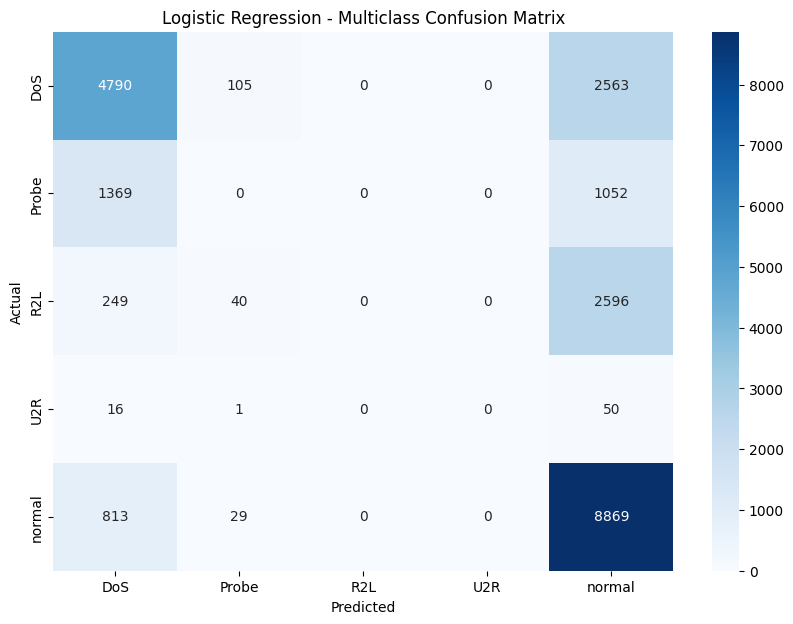


Decision Tree
Accuracy: 0.7615562061928844
              precision    recall  f1-score   support

         DoS       0.95      0.83      0.89      7458
       Probe       0.67      0.60      0.63      2421
         R2L       0.89      0.05      0.10      2885
         U2R       0.54      0.19      0.29        67
      normal       0.68      0.97      0.80      9711

    accuracy                           0.76     22542
   macro avg       0.75      0.53      0.54     22542
weighted avg       0.80      0.76      0.72     22542



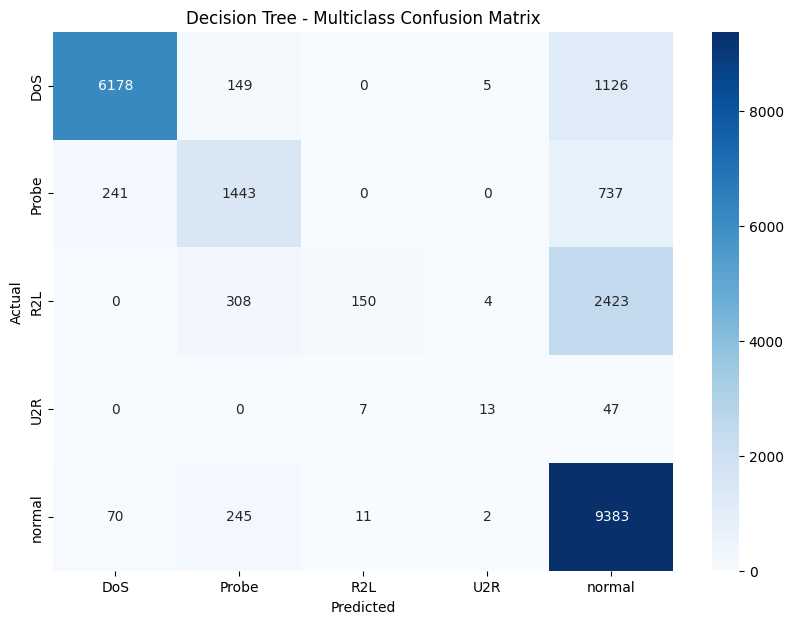


Random Forest
Accuracy: 0.7510868600833999
              precision    recall  f1-score   support

         DoS       0.96      0.77      0.85      7458
       Probe       0.87      0.67      0.75      2421
         R2L       0.99      0.05      0.09      2885
         U2R       0.40      0.03      0.06        67
      normal       0.65      0.97      0.78      9711

    accuracy                           0.75     22542
   macro avg       0.77      0.50      0.51     22542
weighted avg       0.82      0.75      0.71     22542



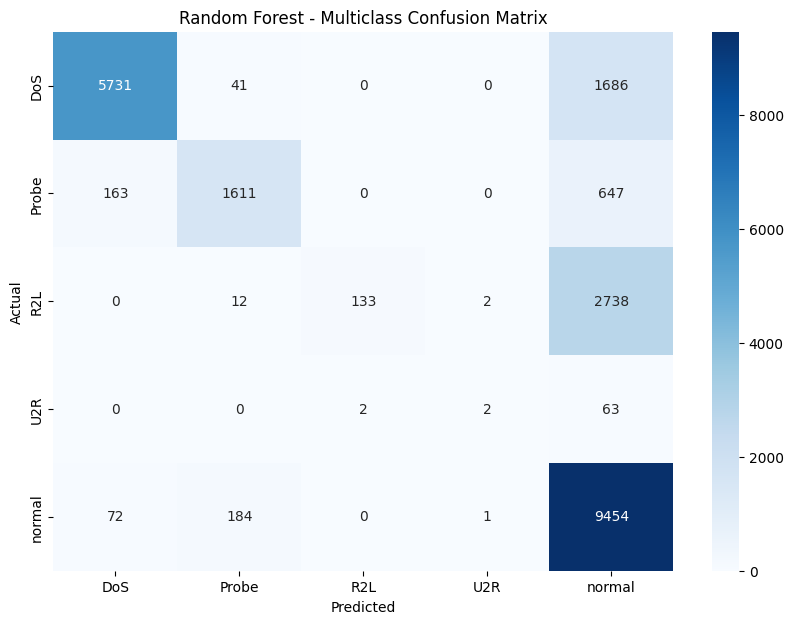


Gradient Boosting
Accuracy: 0.7674563037884837
              precision    recall  f1-score   support

         DoS       0.96      0.82      0.89      7458
       Probe       0.84      0.64      0.73      2421
         R2L       0.98      0.07      0.13      2885
         U2R       0.71      0.25      0.37        67
      normal       0.67      0.97      0.79      9711

    accuracy                           0.77     22542
   macro avg       0.83      0.55      0.58     22542
weighted avg       0.82      0.77      0.73     22542



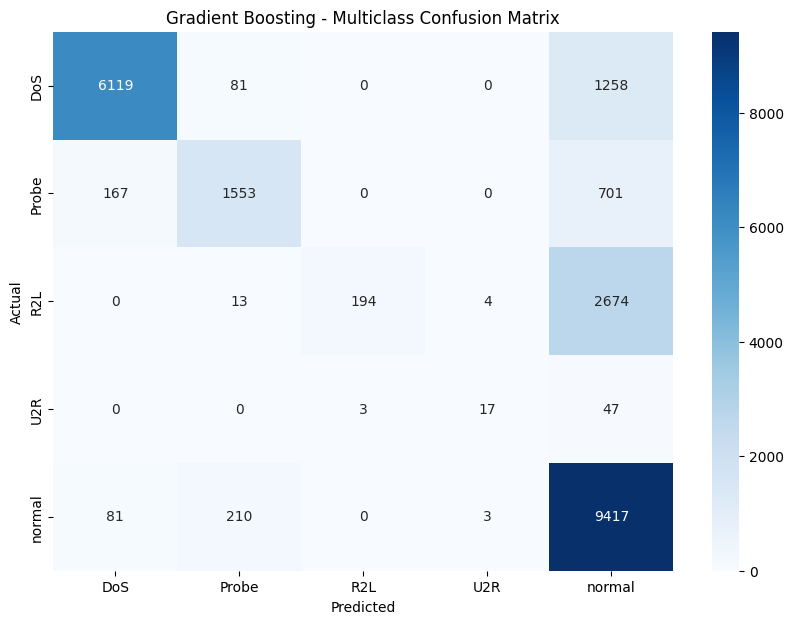

In [55]:
# Get the unique class labels for the confusion matrix plot
multi_class_labels = sorted(y_train_multi.unique())

print("\n\n=== Multiclass Classification ===")
for name, model in models.items():
    # Train the model on the multiclass training data
    model.fit(X_train_multi, y_train_multi)

    # Make predictions on the test data
    y_pred_multi = model.predict(X_test_multi)

    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_test_multi, y_pred_multi))
    print(classification_report(y_test_multi, y_pred_multi, target_names=multi_class_labels))

    # Generate and plot the confusion matrix
    cm = confusion_matrix(y_test_multi, y_pred_multi, labels=multi_class_labels)
    plt.figure(figsize=(10, 7)) # Adjust figure size for better readability
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=multi_class_labels, yticklabels=multi_class_labels)
    plt.title(f"{name} - Multiclass Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [56]:
# Dictionaries to store the results for visualization
binary_results = {}
multi_results = {}

# --- Run Binary Classification and Store Results ---
print("--- Capturing Binary Classification Metrics ---")
for name, model in models.items():
    model.fit(X_train_bin, y_train_bin)
    y_pred = model.predict(X_test_bin)

    # Calculate metrics
    acc = accuracy_score(y_test_bin, y_pred)
    f1 = f1_score(y_test_bin, y_pred, average='weighted')

    # Store metrics
    binary_results[name] = {'Accuracy': acc, 'F1-Score': f1}
    print(f"{name} (Binary) -> Accuracy: {acc:.4f}, F1-Score: {f1:.4f}")

# --- Run Multiclass Classification and Store Results ---
print("\n--- Capturing Multiclass Classification Metrics ---")
for name, model in models.items():
    model.fit(X_train_multi, y_train_multi)
    y_pred_multi = model.predict(X_test_multi)

    # Calculate metrics
    acc_multi = accuracy_score(y_test_multi, y_pred_multi)
    f1_multi = f1_score(y_test_multi, y_pred_multi, average='weighted')

    # Store metrics
    multi_results[name] = {'Accuracy': acc_multi, 'F1-Score': f1_multi}
    print(f"{name} (Multiclass) -> Accuracy: {acc_multi:.4f}, F1-Score: {f1_multi:.4f}")

--- Capturing Binary Classification Metrics ---
Logistic Regression (Binary) -> Accuracy: 0.7539, F1-Score: 0.7516
Decision Tree (Binary) -> Accuracy: 0.7885, F1-Score: 0.7867
Random Forest (Binary) -> Accuracy: 0.7707, F1-Score: 0.7676
Gradient Boosting (Binary) -> Accuracy: 0.8064, F1-Score: 0.8055

--- Capturing Multiclass Classification Metrics ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression (Multiclass) -> Accuracy: 0.6059, F1-Score: 0.5233
Decision Tree (Multiclass) -> Accuracy: 0.7616, F1-Score: 0.7195
Random Forest (Multiclass) -> Accuracy: 0.7511, F1-Score: 0.7102
Gradient Boosting (Multiclass) -> Accuracy: 0.7675, F1-Score: 0.7289


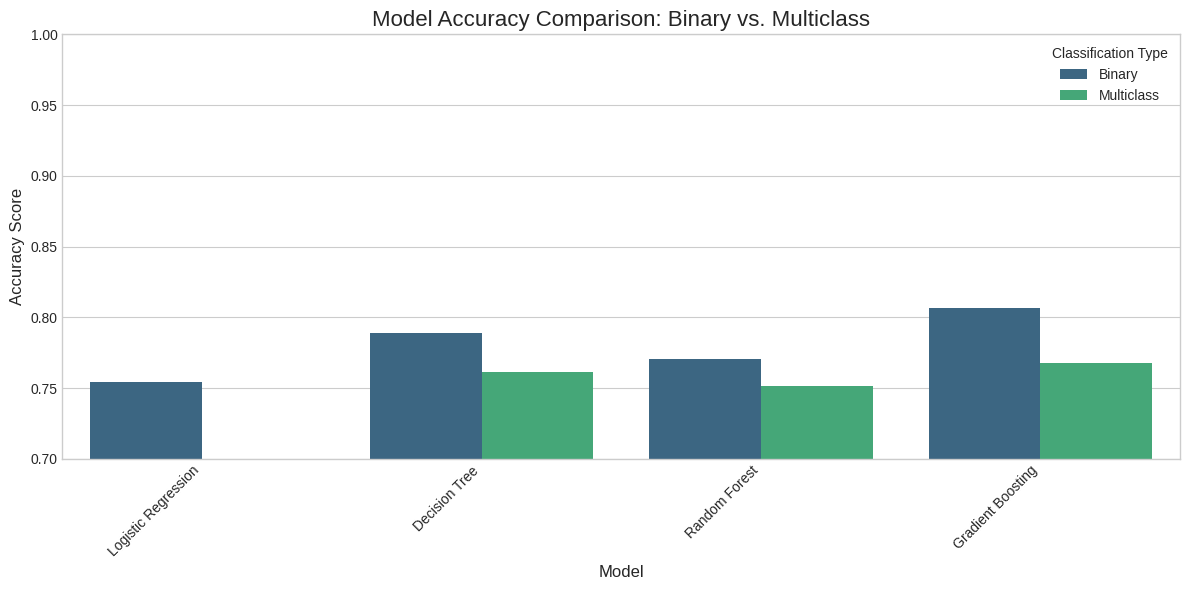

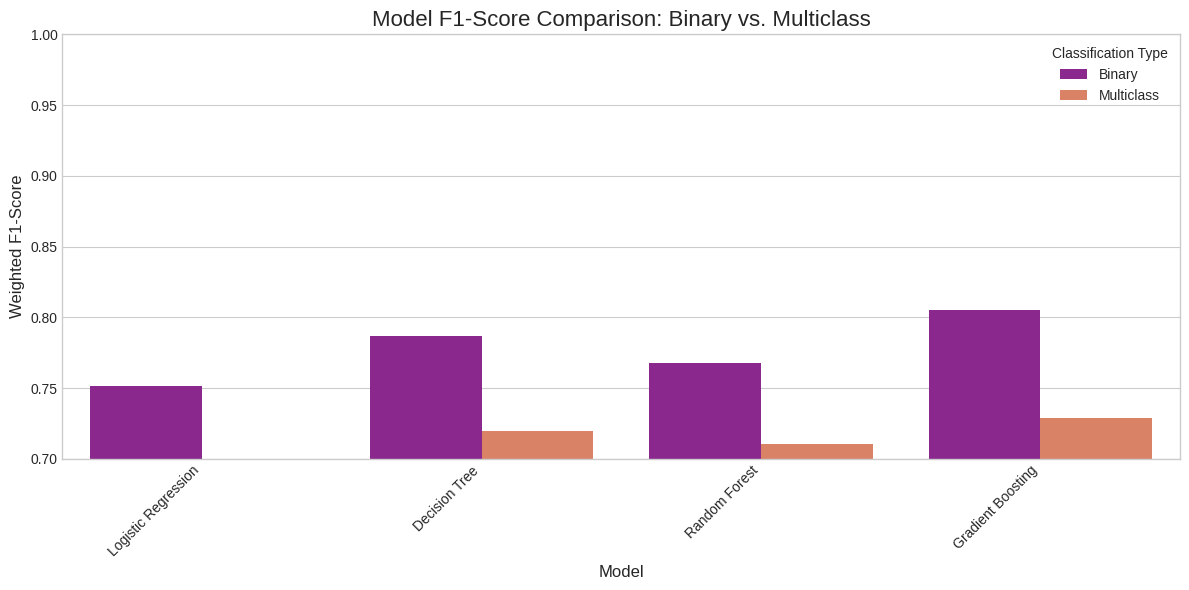

In [57]:
# Convert results to pandas DataFrames
binary_df = pd.DataFrame.from_dict(binary_results, orient='index').reset_index().rename(columns={'index': 'Model'})
multi_df = pd.DataFrame.from_dict(multi_results, orient='index').reset_index().rename(columns={'index': 'Model'})

# Add a column to specify the classification type
binary_df['Type'] = 'Binary'
multi_df['Type'] = 'Multiclass'

# Combine the dataframes for easy plotting
results_df = pd.concat([binary_df, multi_df])

# --- Plotting ---
plt.style.use('seaborn-v0_8-whitegrid') # Using a nice style for the plots

# 1. Accuracy Comparison Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x='Model', y='Accuracy', hue='Type', palette='viridis')
plt.title('Model Accuracy Comparison: Binary vs. Multiclass', fontsize=16)
plt.ylabel('Accuracy Score', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0.7, 1.0) # Adjust ylim to better see differences
plt.legend(title='Classification Type')
plt.tight_layout()
plt.show()

# 2. F1-Score Comparison Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x='Model', y='F1-Score', hue='Type', palette='plasma')
plt.title('Model F1-Score Comparison: Binary vs. Multiclass', fontsize=16)
plt.ylabel('Weighted F1-Score', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0.7, 1.0) # Adjust ylim to better see differences
plt.legend(title='Classification Type')
plt.tight_layout()
plt.show()